Resultados de 100000 lanzamientos:
Probabilidad de cara  (< 0.5):  0.4921
Probabilidad de sello (> 0.5):  0.4884
Probabilidad de canto (entre 0.5 y 0.5): 0.0194


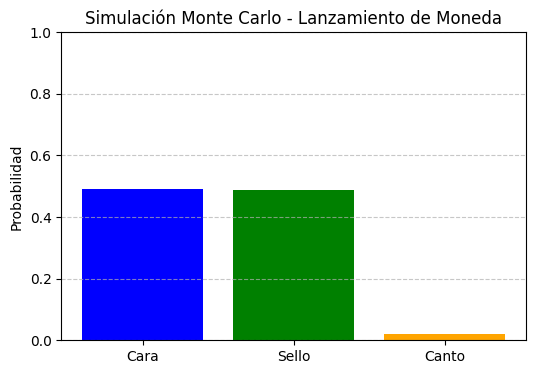

Numero de cantos: 1944


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la simulación
num_simulaciones = 100_000  # Número de lanzamientos de moneda

# Simulación: se generan valores aleatorios entre 0 y 1
valores = np.random.rand(num_simulaciones)

# Clasificación de resultados
caras = np.sum(valores < 0.49)
sellos = np.sum(valores > 0.51)
cantos = np.sum((valores >= 0.49) & (valores <= 0.51))

# Cálculo de probabilidades
prob_cara = caras / num_simulaciones
prob_sello = sellos / num_simulaciones
prob_canto = cantos / num_simulaciones

# Mostrar resultados
print(f"Resultados de {num_simulaciones} lanzamientos:")
print(f"Probabilidad de cara  (< 0.5):  {prob_cara:.4f}")
print(f"Probabilidad de sello (> 0.5):  {prob_sello:.4f}")
print(f"Probabilidad de canto (entre 0.5 y 0.5): {prob_canto:.4f}")

# Visualización
etiquetas = ['Cara', 'Sello', 'Canto']
valores = [prob_cara, prob_sello, prob_canto]

plt.figure(figsize=(6,4))
plt.bar(etiquetas, valores, color=['blue', 'green', 'orange'])
plt.title('Simulación Monte Carlo - Lanzamiento de Moneda')
plt.ylabel('Probabilidad')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print(f'Numero de cantos: {cantos}')

Ejercicio 2: Estimación del valor del número Pi.
En este ejercicio calcularemos el valor del número Pi por medio de la comparación de las áreas de un cuadrado de lado L=2 y el área de un círculo inscrito de radio r=1. ¿Cómo funciona este método? Dejaremos caer puntos (muchos) aleatoriamente y uniformemente sobre la figura. Contaremos los puntos que caen dentro del círculo y los que caen dentro del cuadrado completo. La razón entre ambos números corresponde a la razón entre las áreas, pues:

Área círculo/Área cuadrado = pi * r^2 / L * L = pi * r^2 / (2r) * (2r) =pi * r^2 / 4r^2 (dado que L = 2r) Luego, podemos ver que: Área círculo / Área cuadrado = pi / 4 En este caso, las áreas de las figuras se aproximan por el número de puntos que caen dentro de las respectivas figuras, por lo que podemos despejar el valor de pi tal que: Pi = 4 * N° puntos dentro del círculo / N° puntos dentro del cuadrado.

Repita el experimento utilizando 1000 puntos por cada realización del experimento. Primero, repita el experimento 100 veces, realice un histograma de los 100 valores estimados de pi y obtenga su valor de pi como el promedio de los resultados de los experimentos; además, reporte un intervalo de confianza de 95% para la estimación de pi. Esto último se realiza sabiendo que el 95% corresponde a ± 1.96*sigma, donde sigma es la desviación estándar. Posteriormente, repita el experimento 50.000 veces, realice un histograma de sus resultados y estime el valor de pi y entregue un intervalo de confianza del 95 %. Marque en sus histogramas los valores promedio con una linea vertical continua y el ±95 % con una linea vertical entrecortada (utilice el comando vlines de Pyplot) para ambos casos. ¿Qué puede decir de la distribución de valores obtenidos al repetir el experimento más veces? ¿Tiene sentido el valor del intervalo de confianza con el valor real de pi?

7845
3.138


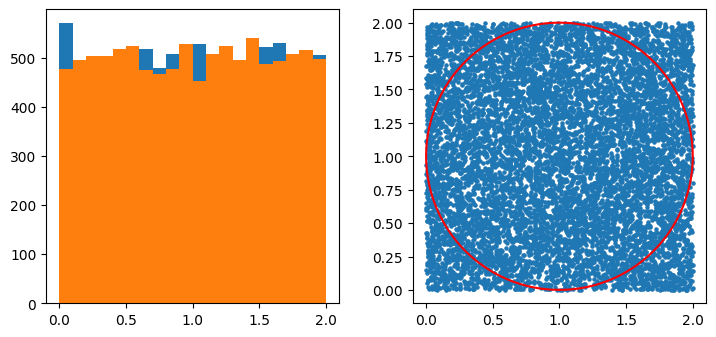

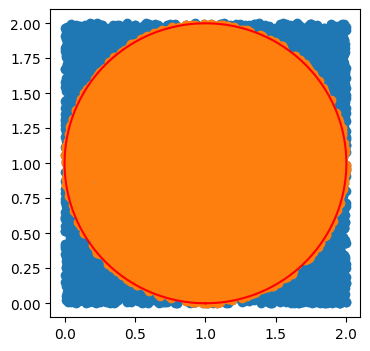

In [23]:
L = 2
r= 1
#muestra aleatoria de puntos para eje x
#px = 2 * np.random.random_sample(1000)
n=10000
px=np.random.uniform(0,2,n)
#muestra aleatoria de puntos para eje y
#py = 2 * np.random.random_sample(1000)
py=np.random.uniform(0,2,n)
f,ax = plt.subplots(1,2,figsize=[8,3.5],sharex='col',sharey=False)
f.subplots_adjust(hspace=0,wspace=0.25,right=0.95, bottom=0.1, top = 0.94)

ax[0].hist(px,bins=20)
ax[0].hist(py,bins=20)

ax[1].scatter(px,py,s=5)
#circulo
z=np.linspace(2,0,1000)
y=np.linspace(0,2,1000)
a = np.sqrt(1-(y-1)**2) + 1
b = -np.sqrt(1-(y-1)**2) + 1
x = np.append(a,b)
y = np.append(y,z)
ax[1].plot(x,y,c='r')
mask = (px - 1)**2 + (py-1)**2 <= 1

print(len(px[mask]))

mask = (px - 1)**2 + (py-1)**2 <= 1
plt.figure(figsize=[4,4])
plt.scatter(px,py)
plt.scatter(px[mask],py[mask])
plt.plot(x,y,c='r')

print(4 * (len(py[mask]) / len(py)))

np.float64(3.1409059999999998)

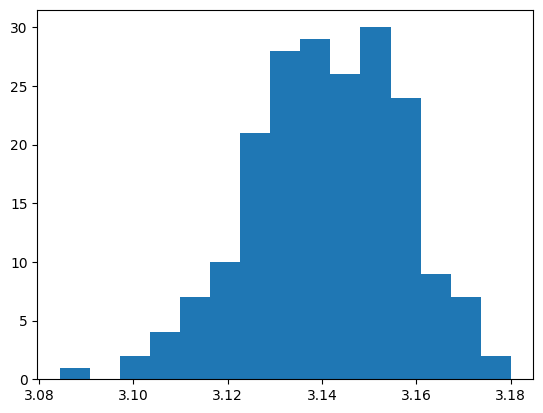

In [26]:
COUNT = []
for i in range(200):
    np.random.seed(i)
    px=np.random.uniform(0,2,10000)
    #muestra aleatoria de puntoS
    py=np.random.uniform(0,2,10000)
    mask = (px - 1)**2 + (py-1)**2 <= 1
    #Pi = 4 * N° puntos dentro del círculo / N° puntos dentro del cuadrado.
    COUNT += [4 * (len(py[mask]) / len(py))] #lo que importa realmente es el numero de pts en el circ
    # el cuadrado tendra siempre la misma cantidad de pts
plt.hist(COUNT,bins=15)
np.mean(COUNT)